# T24 — Comparing Alternative Paleomagnetic Reference Frames in Reconstructions

In T23 we built a paleomagnetic reference frame from the GPMDB (https://www.earth.northwestern.edu/~amir/gpmdb/) and embedded it in the Zahirovic2022 rotation file as anchor plate **701702**, alongside the model's built-in paleomagnetic frame (**701701**). Here the comparison becomes tangible: reconstructions at key times with the built-in frame as a filled grey base layer and our GPMDB frame overlain as thin red outlines, paleolatitude histories of key continents under both frames, and an MP4 animation through the model's full 410–0 Ma span at a user-set cadence.

## Learning objectives

- Reconstruct with alternative anchor plates (`anchor_plate_id`) in GPlately/pyGPlates.
- Layer alternative reconstructions legibly on a single pyGMT map (filled base + line overlay).
- Quantify frame differences as paleolatitude histories of key continents.
- Render reconstruction animations (PNG frame loop → ffmpeg MP4).

## Prerequisites and runtime

- T23 executed first (it creates `data/Zahirovic2022_with_gpmdb_frame.rot`).
- `gplately`, `pygmt`, `pygplates`, `ffmpeg` on the PATH for the video.
- Runtime: ~2 minutes for the static maps; the animation takes ~1–2 s per frame (83 frames at 5 Myr cadence).


In [7]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports, versions, plot styling
import os
import subprocess
import numpy as np
import pygplates
import pygmt
import gplately
from plate_model_manager import PlateModelManager

for mod in (np, pygplates, pygmt, gplately):
    print(f"{mod.__name__:20s} {getattr(mod, '__version__', 'n/a')}")

# Plot styling: large, legible fonts for titles, axis labels, annotations and
# colour bars (GMT defaults are far too small for teaching figures).
pygmt.config(FONT_TITLE="18p,Helvetica-Bold,black",
             FONT_LABEL="14p,Helvetica,black",
             FONT_ANNOT_PRIMARY="12p,Helvetica,black")
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


numpy                2.3.2
pygplates            1.0.0
pygmt                v0.18.0
gplately             2.0.0.post19+git.2cce7bb3
gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [8]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
TIME_START_MA        = 0.0           # Ma
TIME_END_MA          = 350.0         # Ma
TIME_STEP_MA         = 10.0          # Ma
ANCHOR_PLATE_ID_A    = 701701        # Reference frame A (default Z2022)
ANCHOR_PLATE_ID_B    = 701702        # Reference frame B (paleomag-derived)
REGION_LAURENTIA     = [50, 150, 250, 350]
# ============================================================================


In [9]:
# Cell 2 — model + augmented rotation file from T22; two reconstruction trees
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

from pathlib import Path as _Path
AUG_ROT = next((str(p) for p in [
    _Path("data/Zahirovic2022_with_gpmdb_frame.rot"),
    _Path("../data/Zahirovic2022_with_gpmdb_frame.rot"),
] if p.exists()), "data/Zahirovic2022_with_gpmdb_frame.rot")   # created in T22
assert os.path.exists(AUG_ROT), "Run T22 first to create the augmented rotation file."

FRAME_A = 701701   # model's built-in paleomagnetic frame (base layer, filled grey)
FRAME_B = 701702   # our GPMDB-derived frame from T22 (overlay, thin blue lines)

recon, gplot = {}, {}
for anchor in (FRAME_A, FRAME_B):
    recon[anchor] = gplately.PlateReconstruction(
        rotation_model=pygplates.RotationModel(AUG_ROT, default_anchor_plate_id=anchor),
        topology_features=model.get_topologies(),
        static_polygons=model.get_static_polygons(),
    )
    gplot[anchor] = gplately.PlotTopologies(recon[anchor], coastlines=model.get_coastlines())
engine = gplately.PygmtPlotEngine()
print("reconstruction trees ready for anchors", list(recon))


reconstruction trees ready for anchors [701701, 701702]


## 1. Layered coastline reconstructions at key times

Plotting two coastline sets as overlapping lines is unreadable; instead the built-in frame (`701701`) is drawn as a **filled grey base layer** and the GPMDB (https://www.earth.northwestern.edu/~amir/gpmdb/) frame (`701702`) is overlain as **thin blue outlines**. Latitudinal offsets between the grey land and the blue outlines are real, meaningful differences; longitudinal offsets partly reflect each frame's longitude convention.


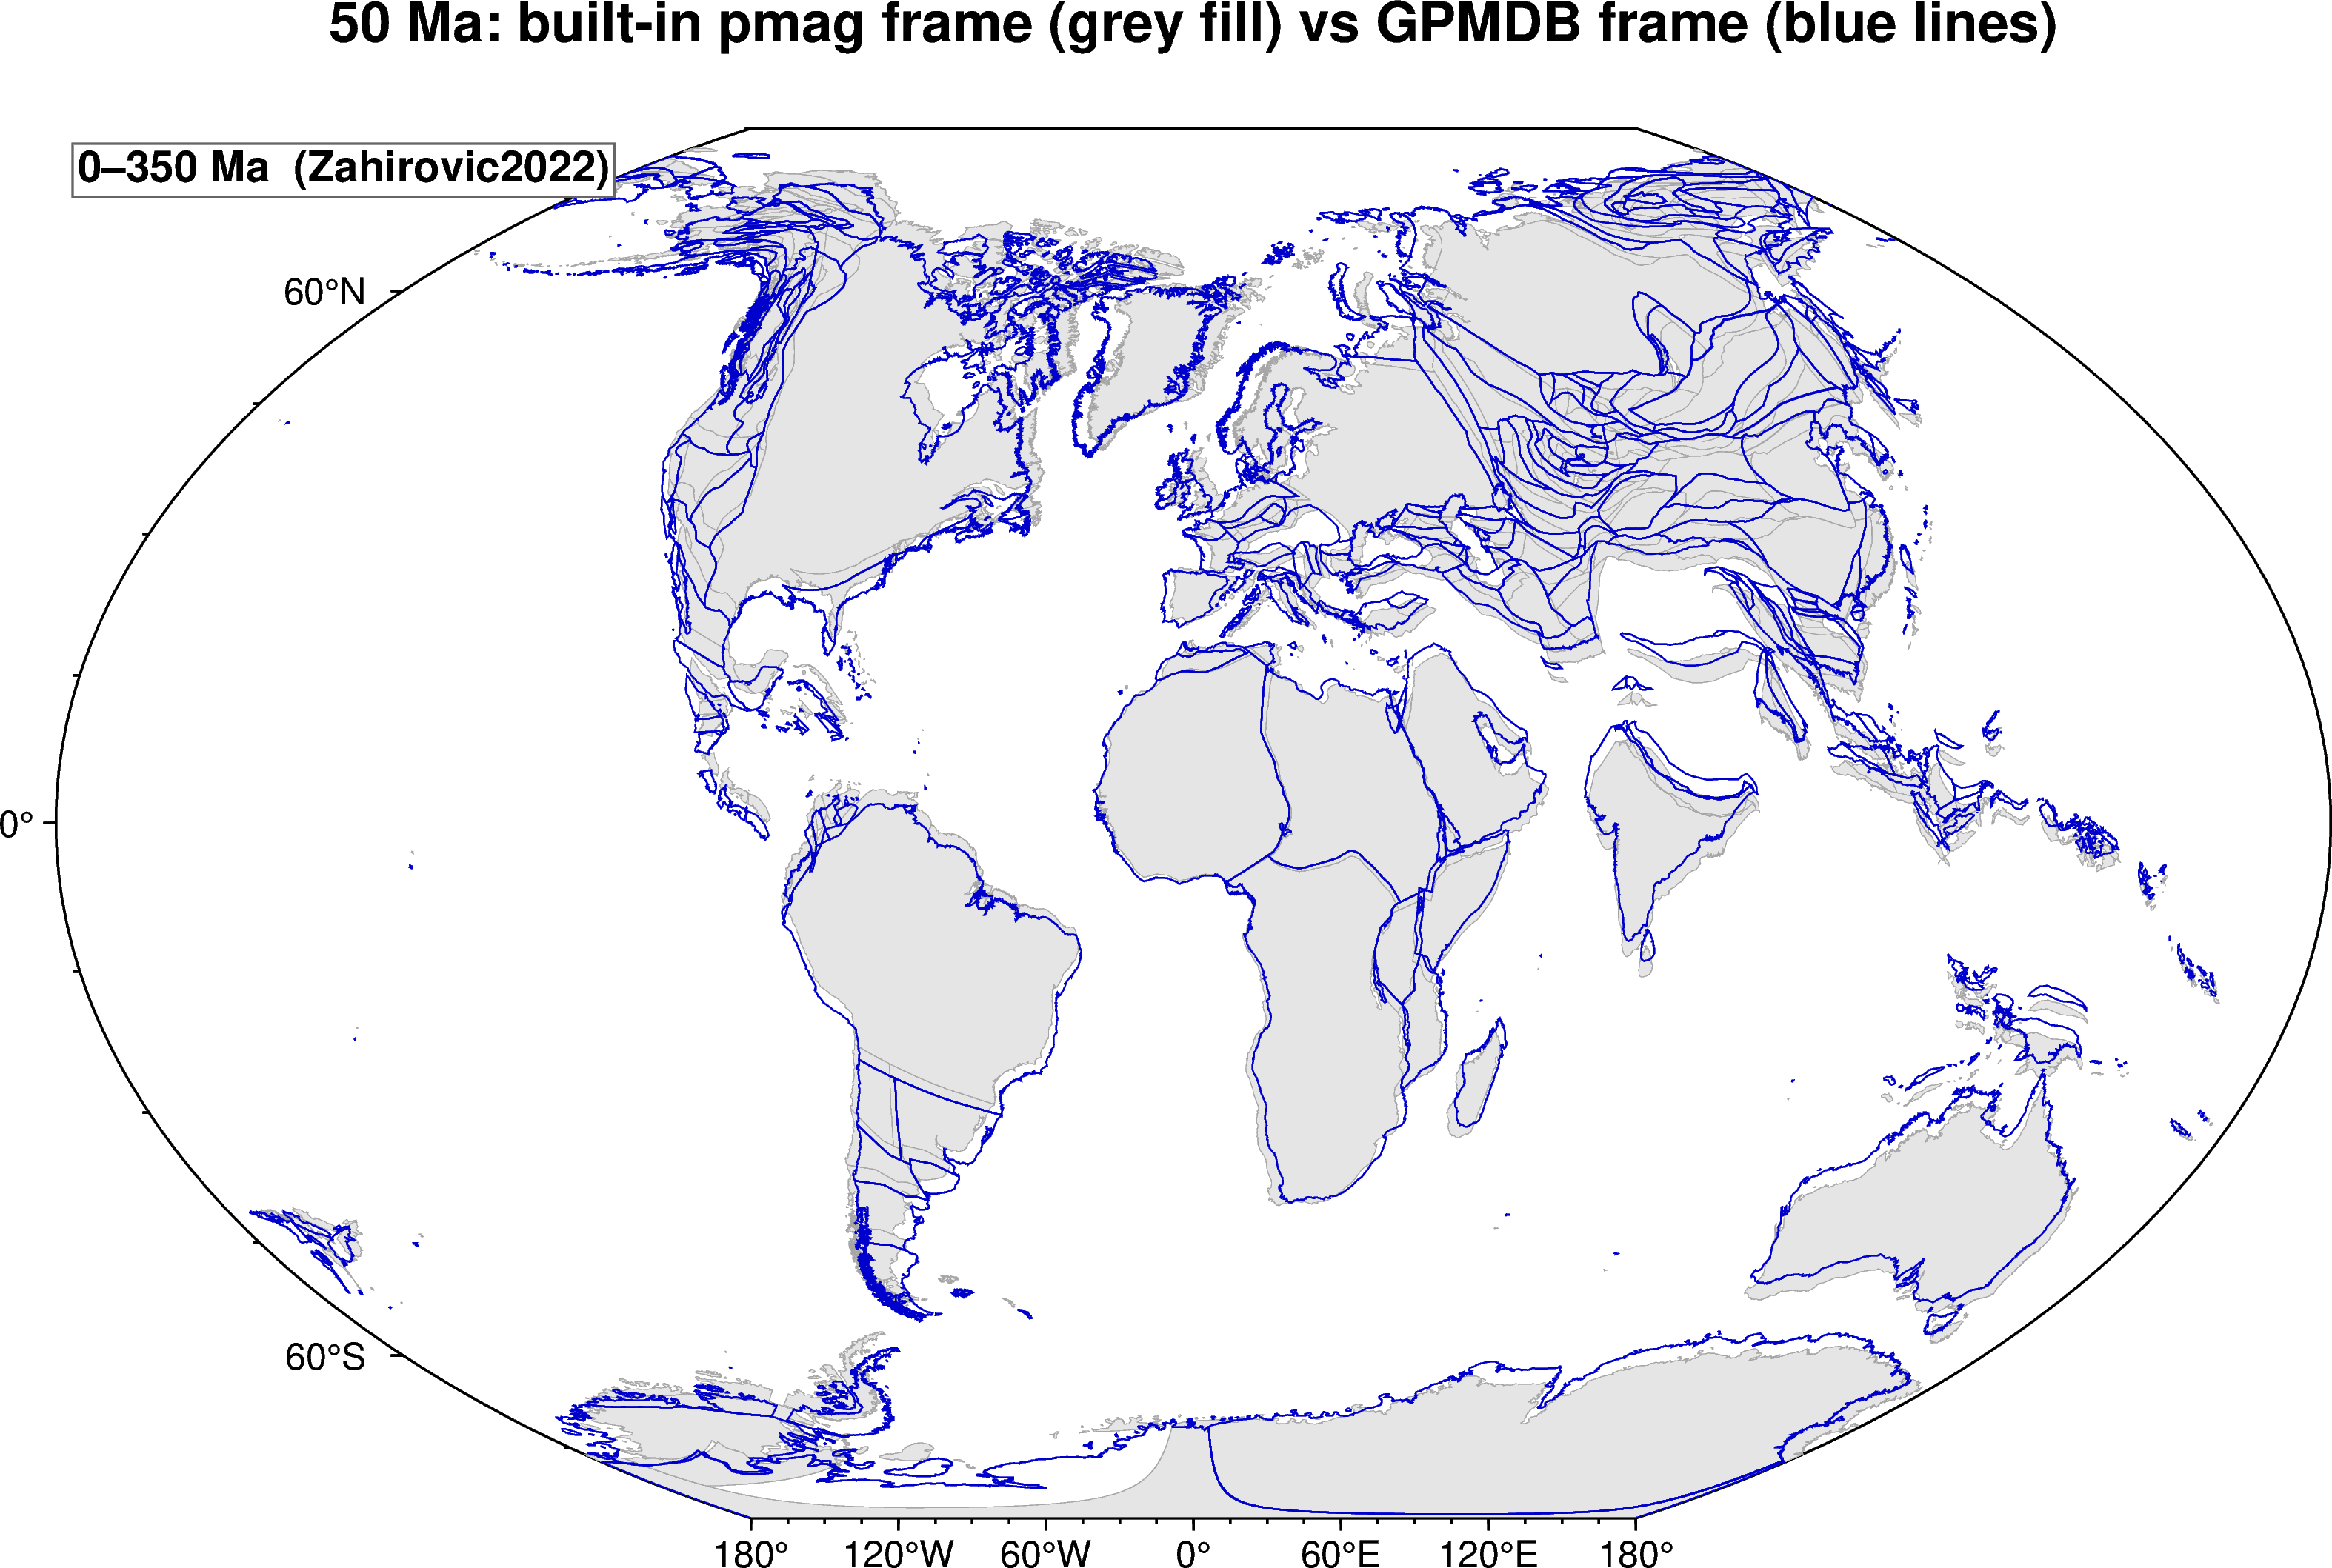

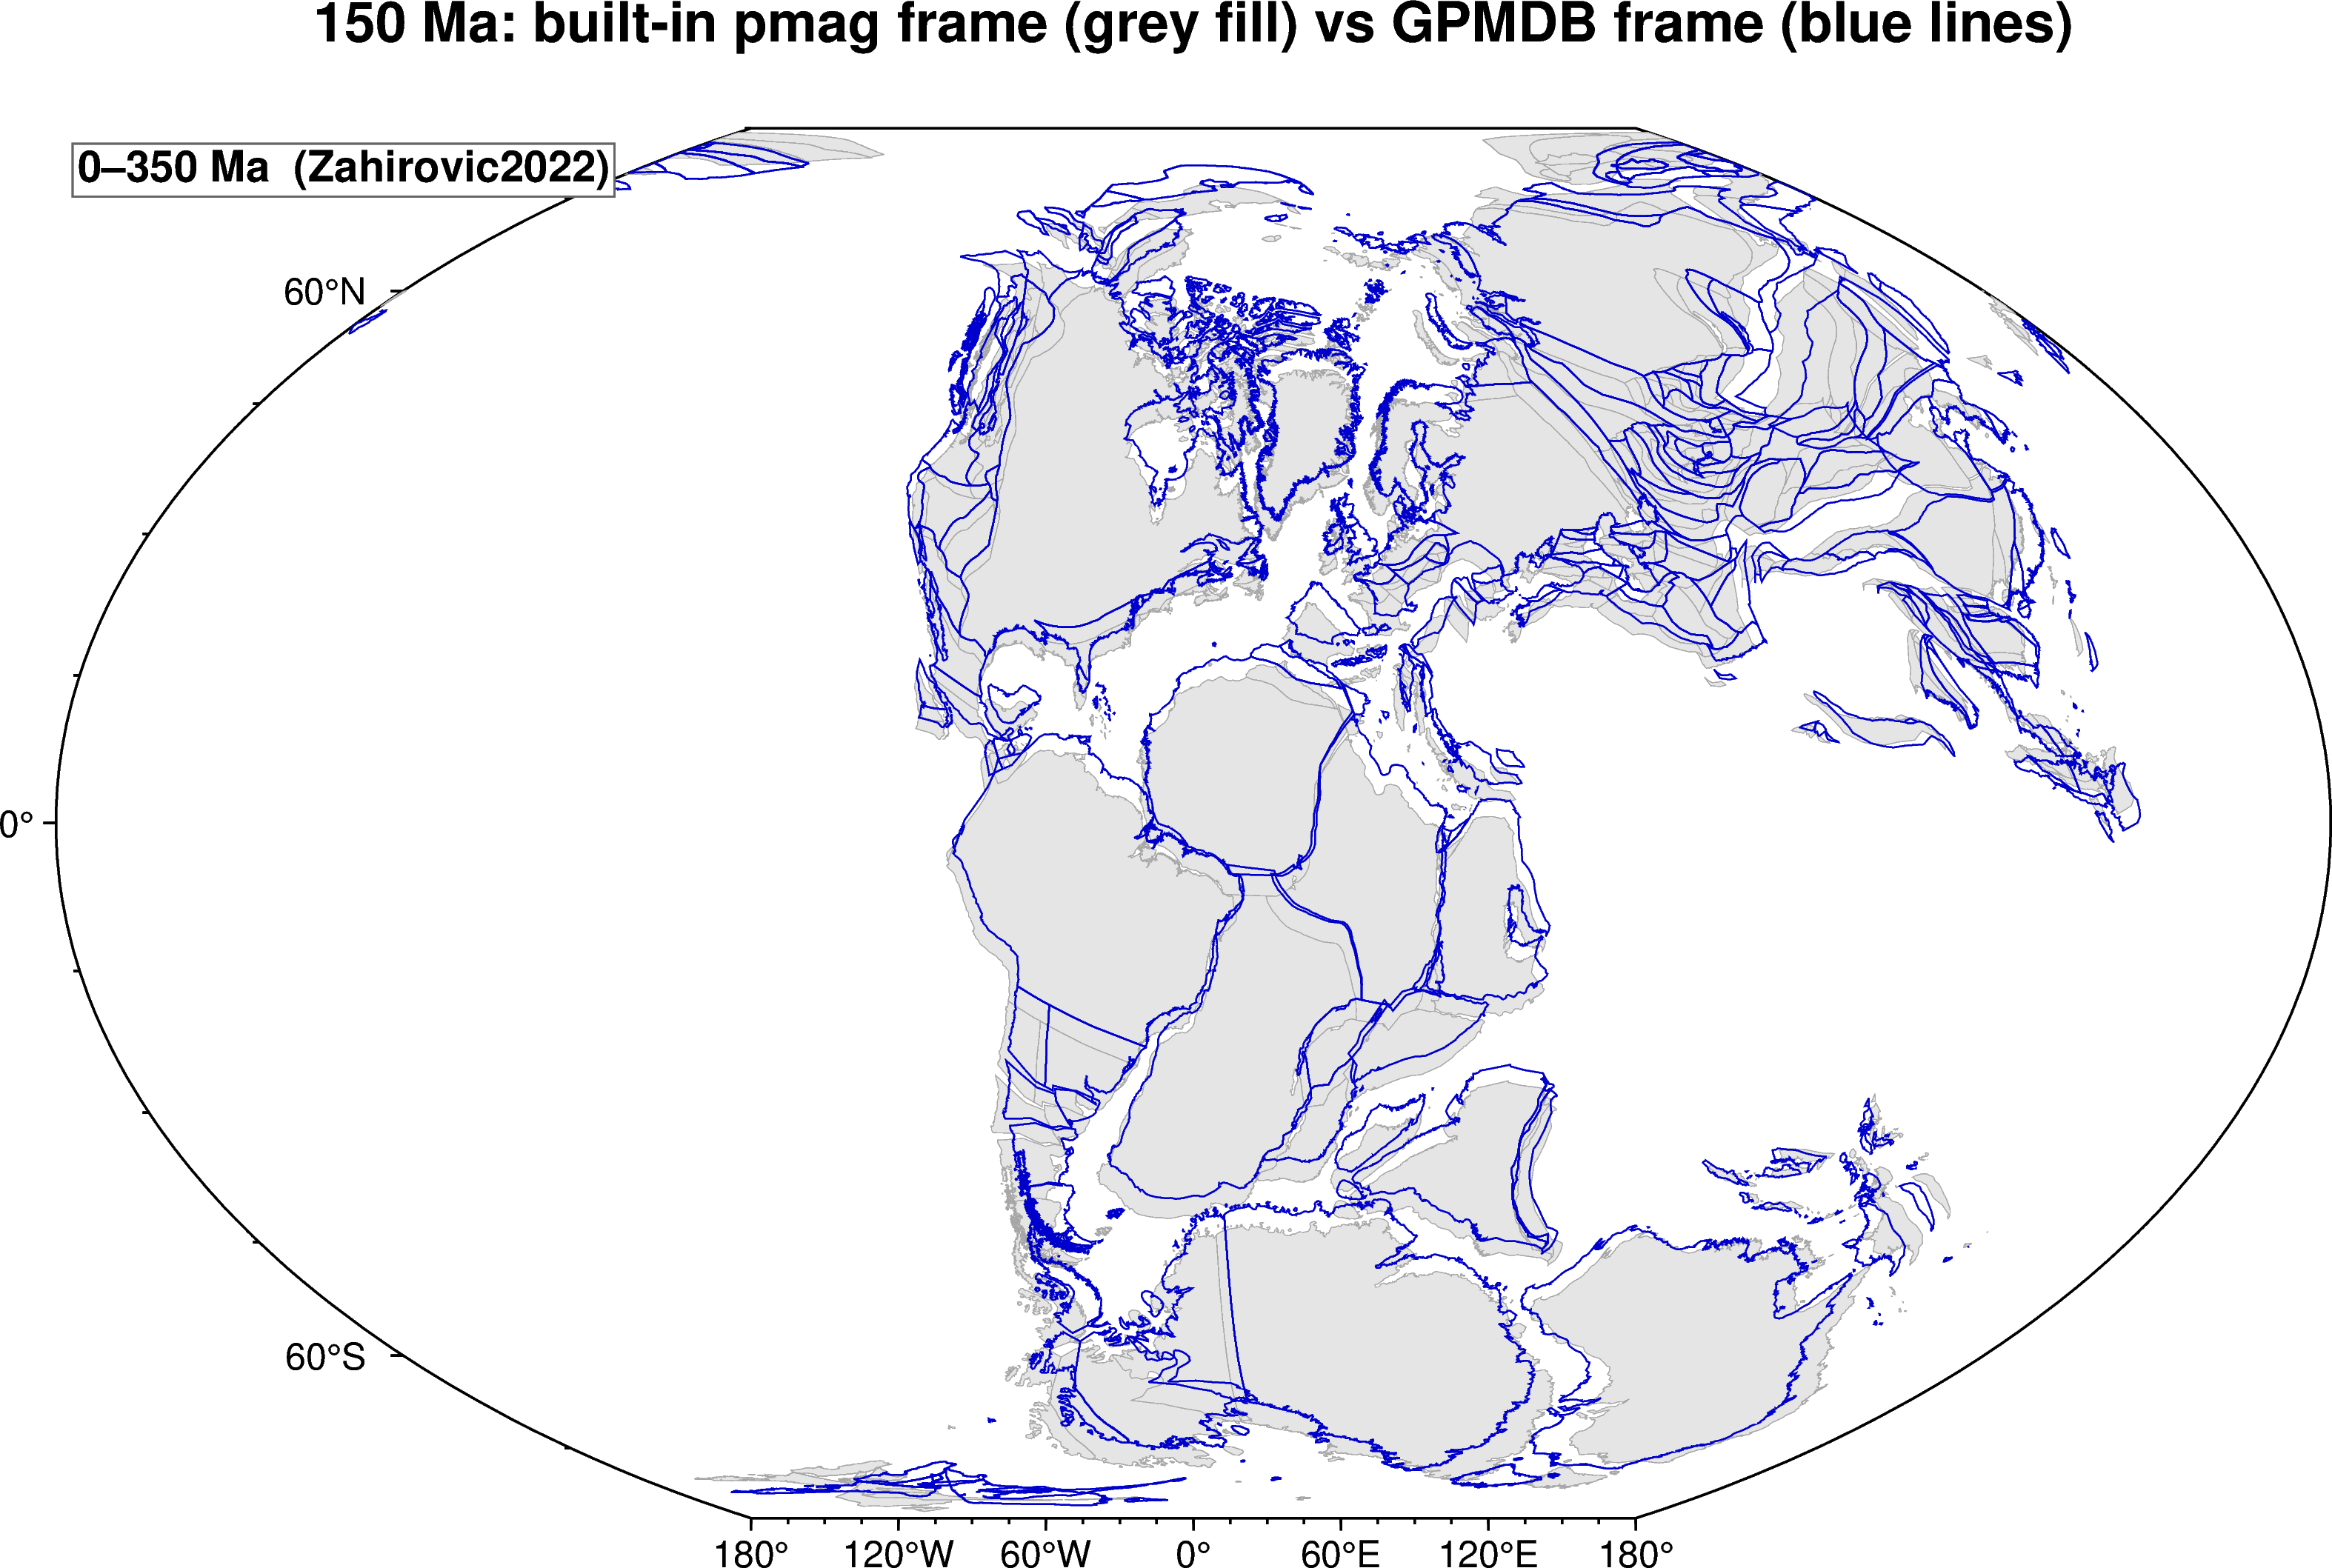

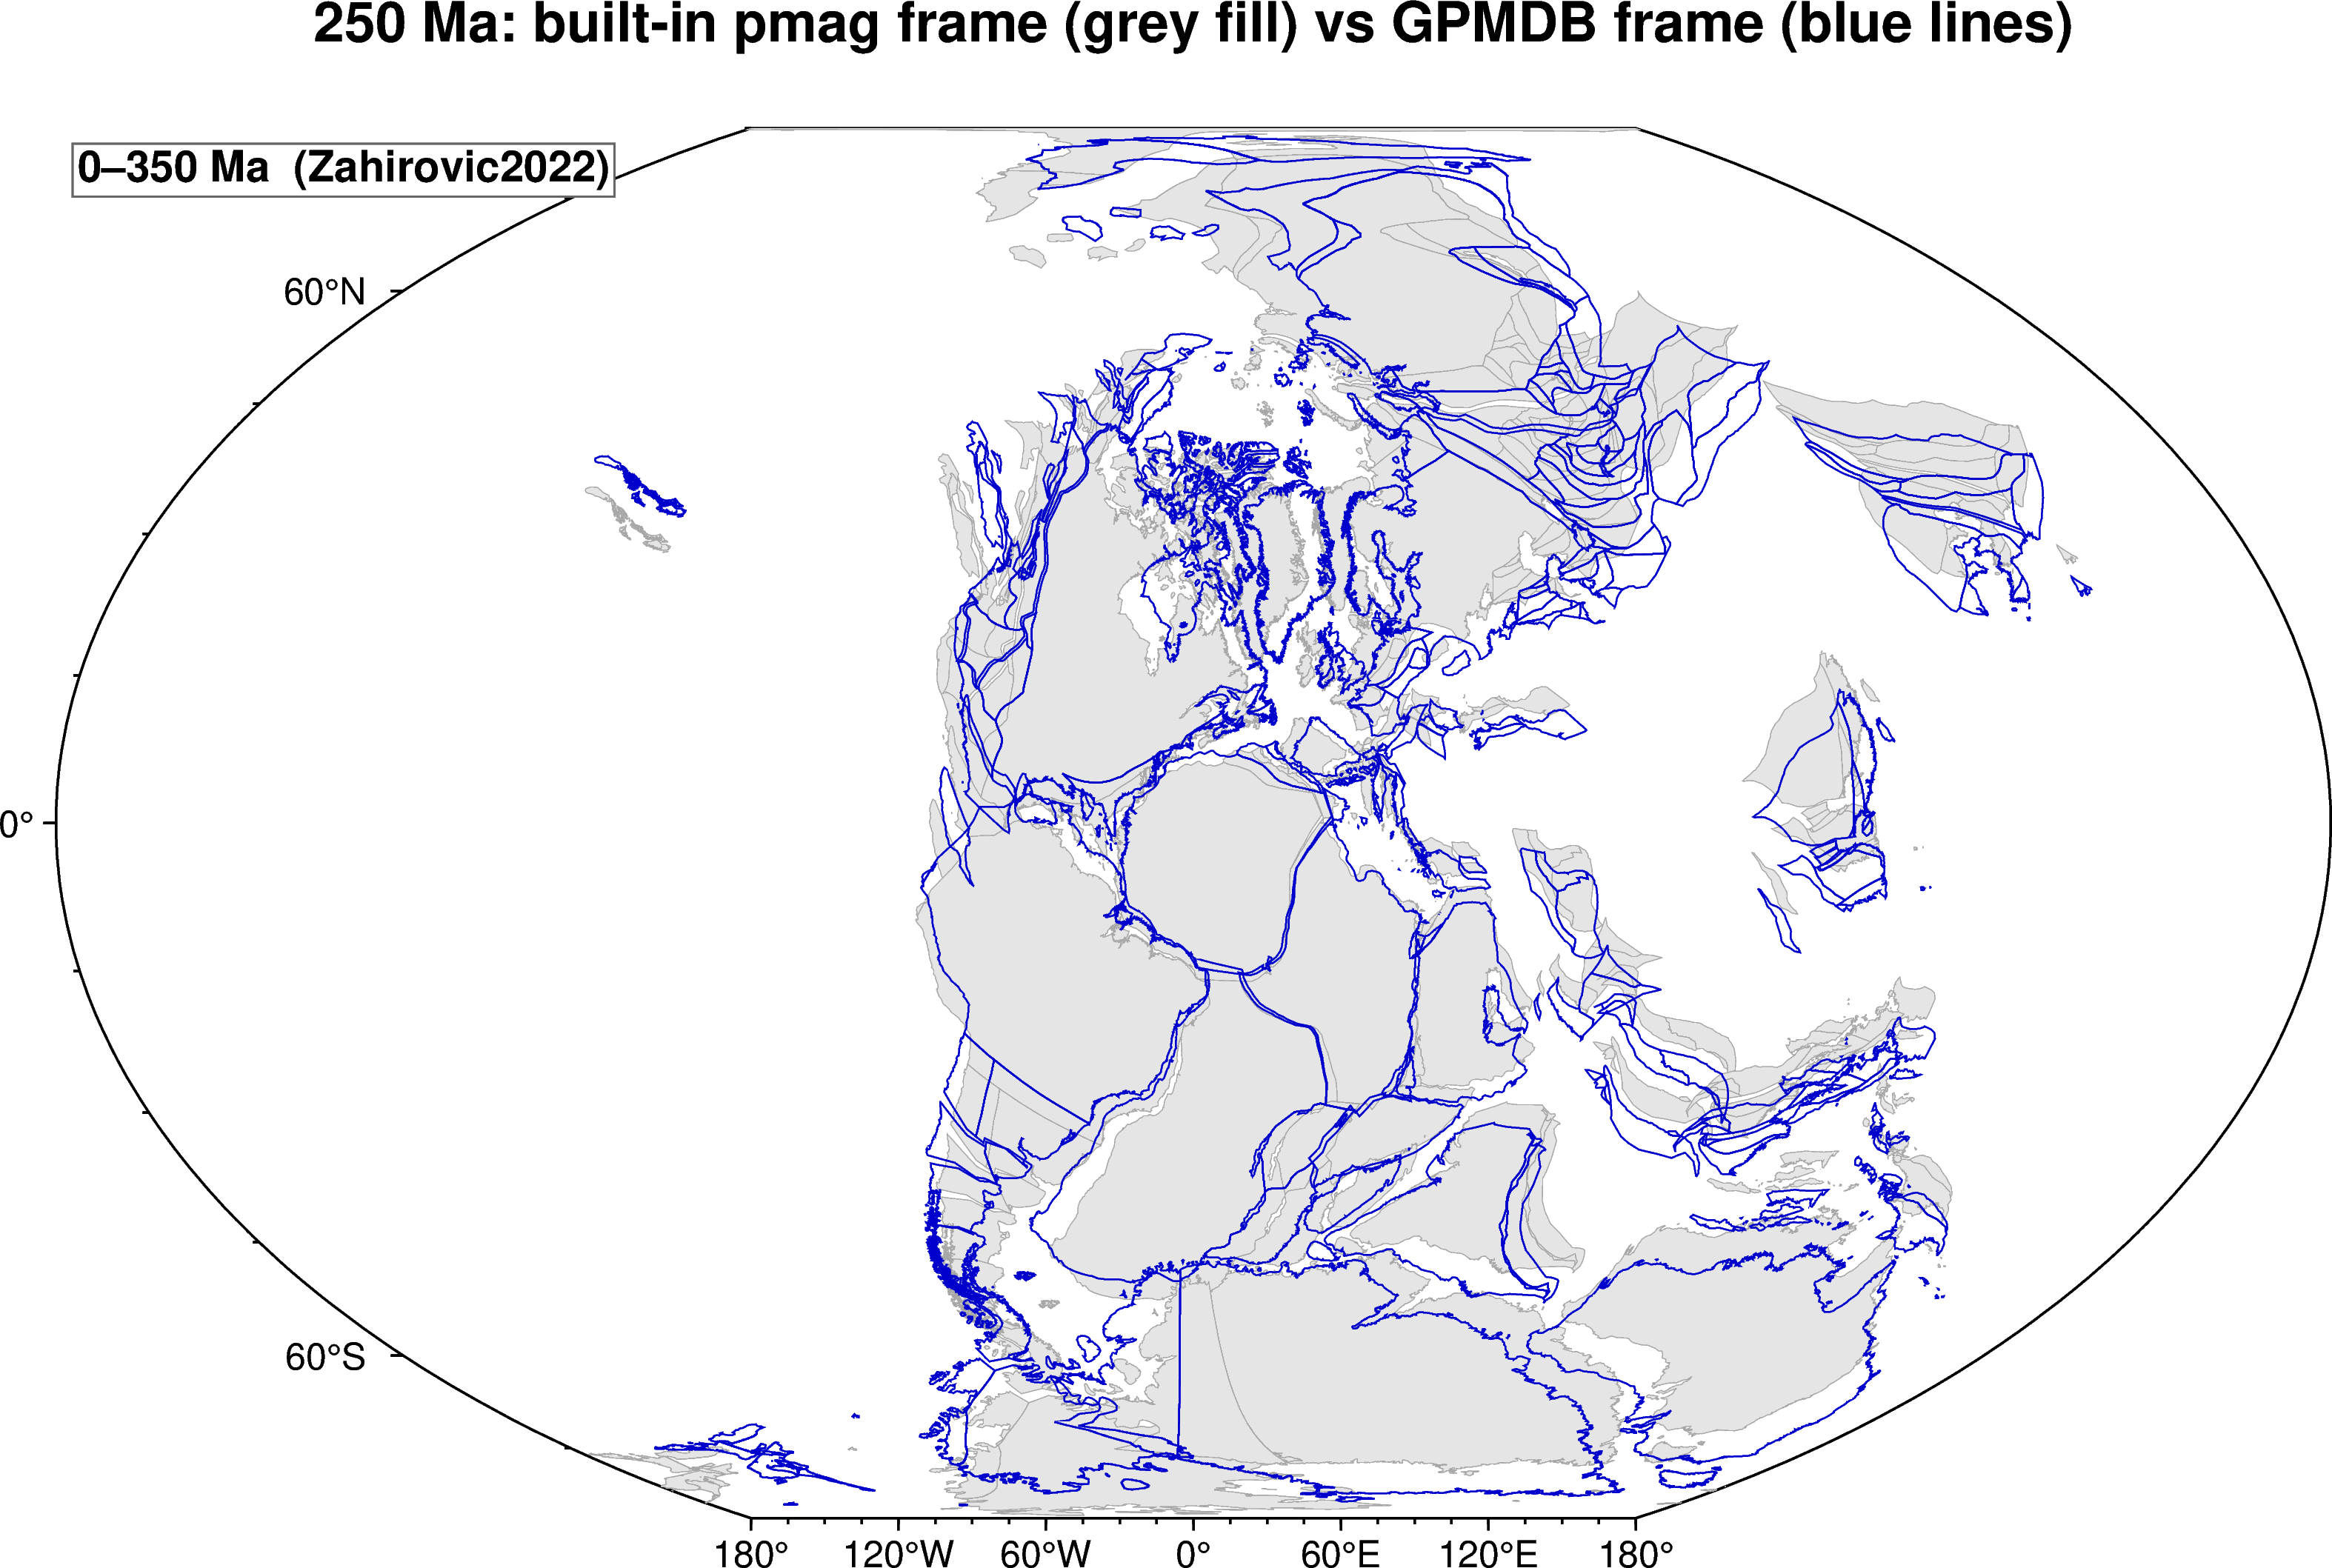

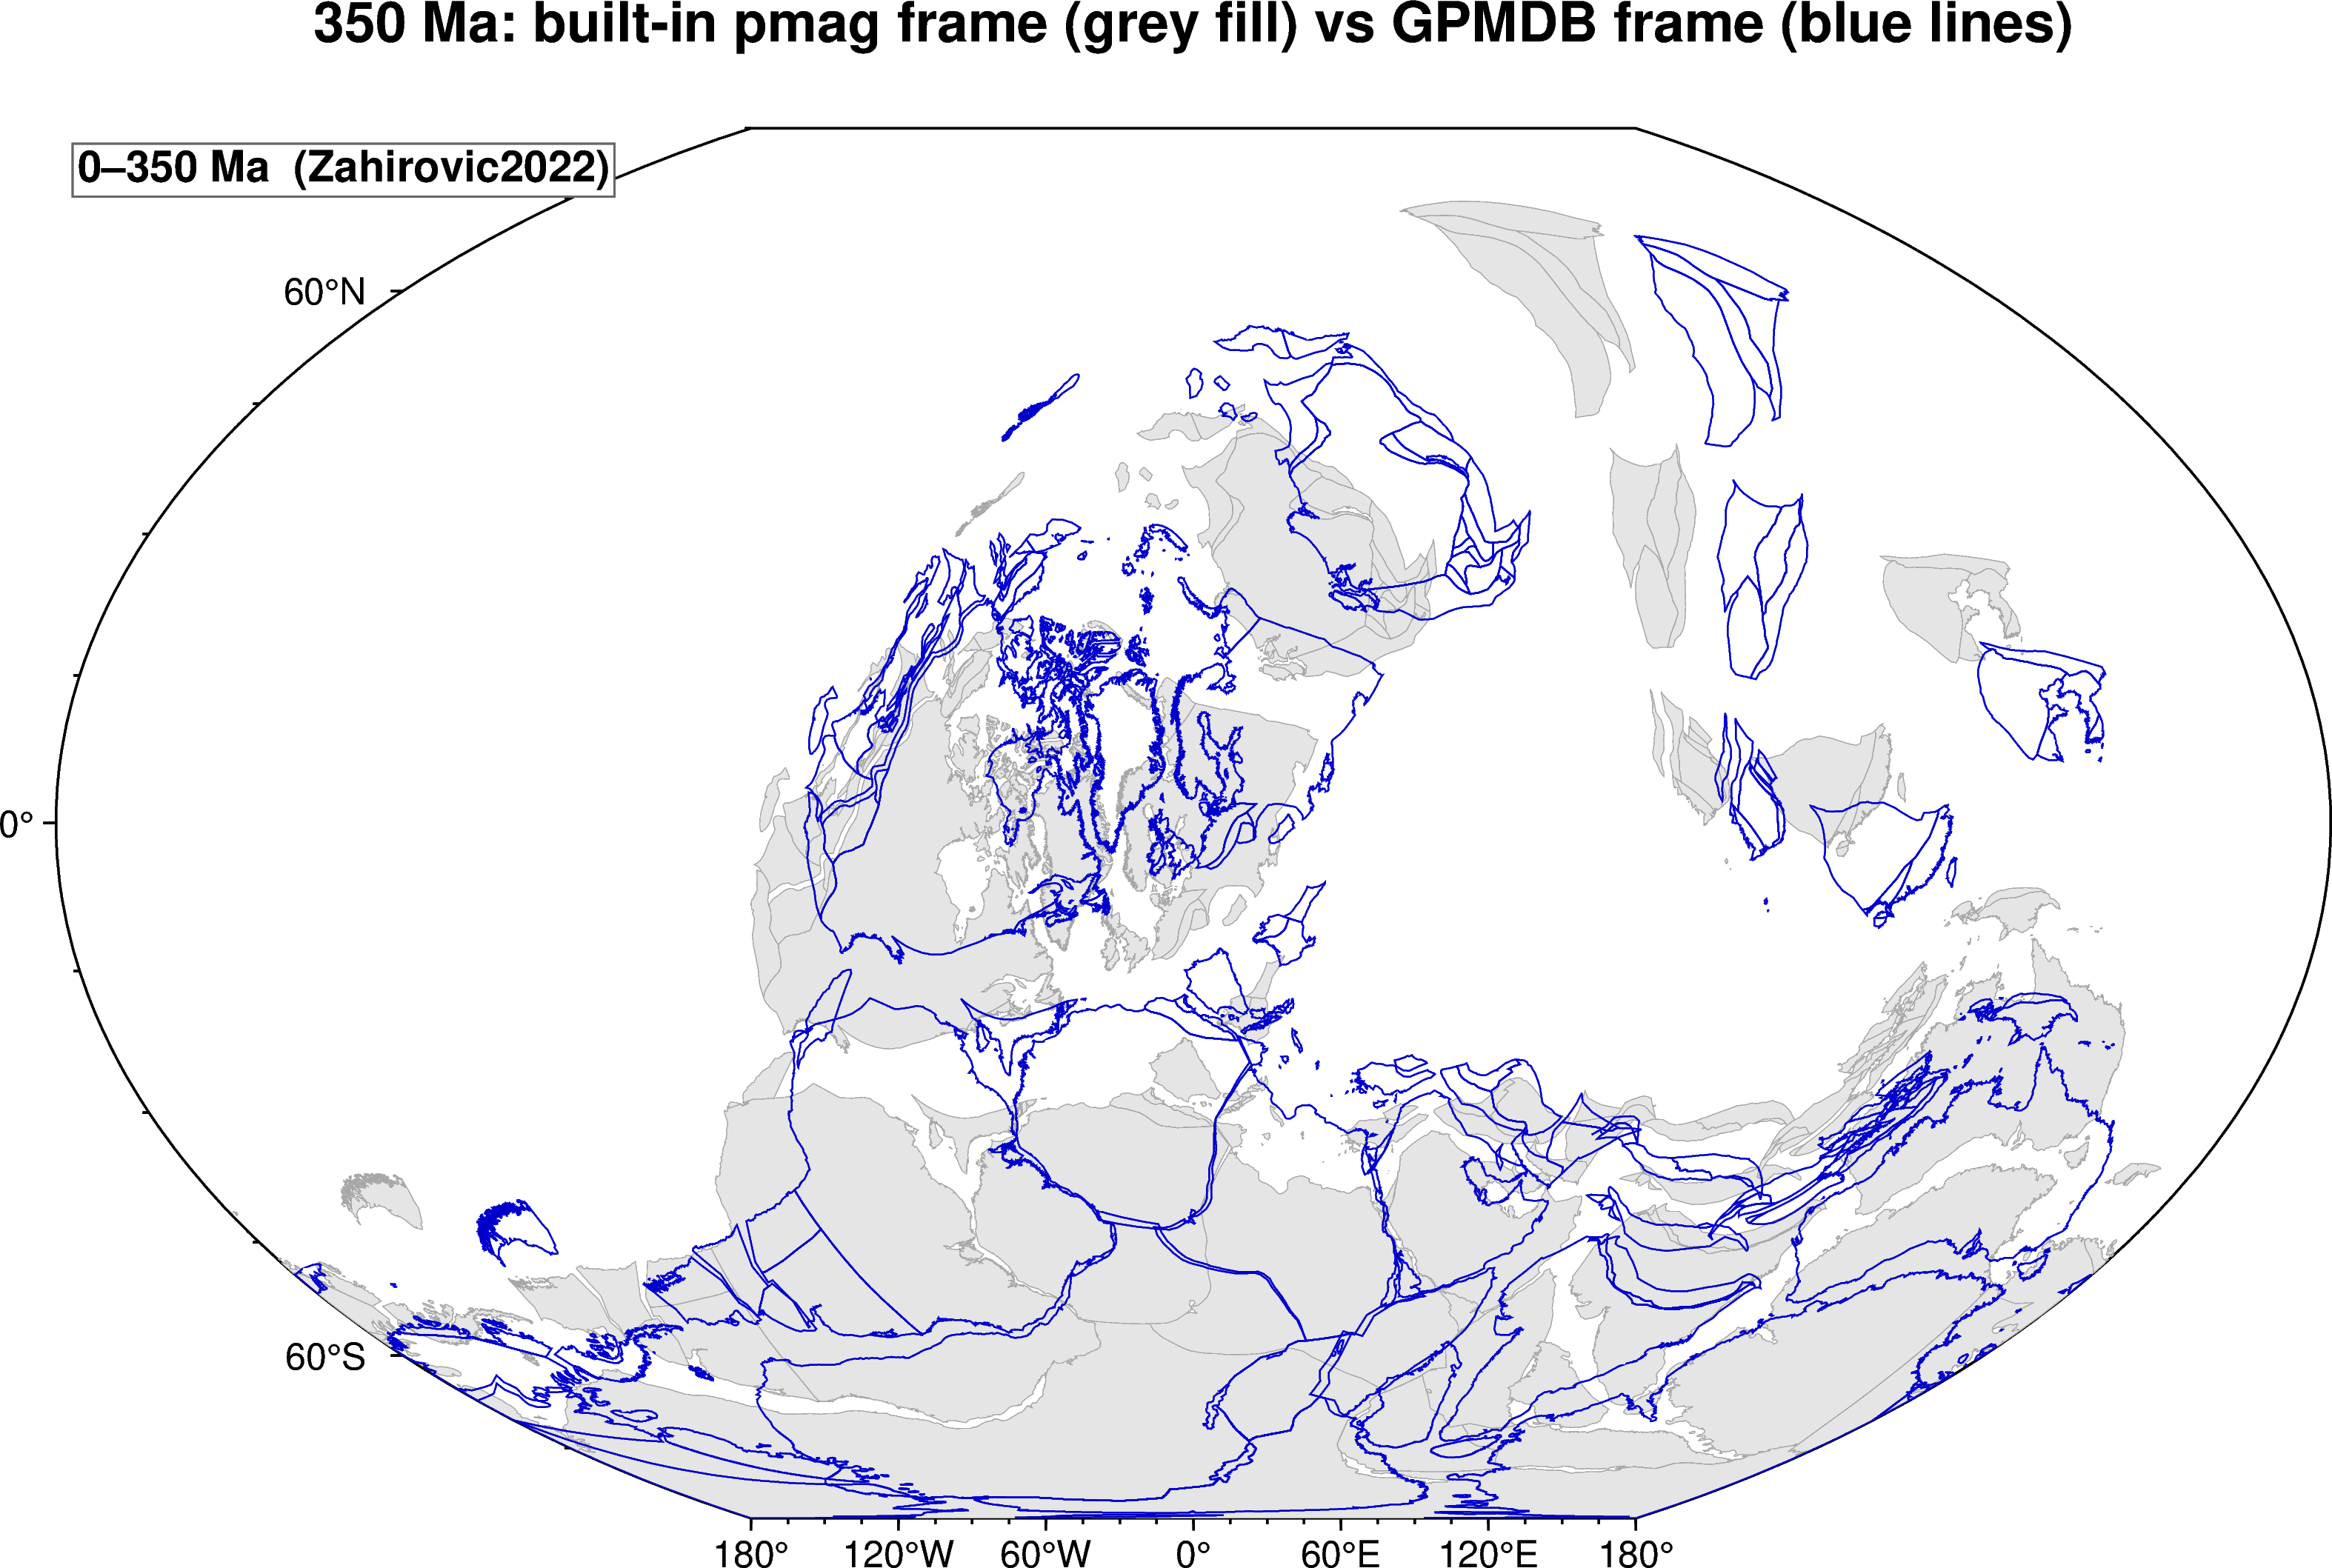

In [10]:
# Cell 3 — key-time comparison maps (filled base + line overlay)
KEY_TIMES = [50, 150, 250, 350]   # Ma — edit freely

def plot_frame_comparison(fig, age):
    gplot[FRAME_A].time = float(age)
    engine.plot_geo_data_frame(fig, gplot[FRAME_A].get_coastlines(),
                               fill="gray90", pen="0.2p,gray65")
    gplot[FRAME_B].time = float(age)
    engine.plot_geo_data_frame(fig, gplot[FRAME_B].get_coastlines(),
                               pen="0.5p,mediumblue")

for age in KEY_TIMES:
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="R0/26c",
                frame=["af", f"+t{age} Ma: built-in pmag frame (grey fill) vs GPMDB frame (blue lines)"])
    plot_frame_comparison(fig, age)
    fig.text(text=f"0–350 Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)


## 2. Paleolatitude of key continents under each frame

Paleolatitude is the quantity a paleomagnetic frame actually constrains, so this is the cleanest quantitative comparison — free of the longitude convention. We track reference points in the interiors of Africa, North America and Australia, with each panel's y-range fitted to its data.


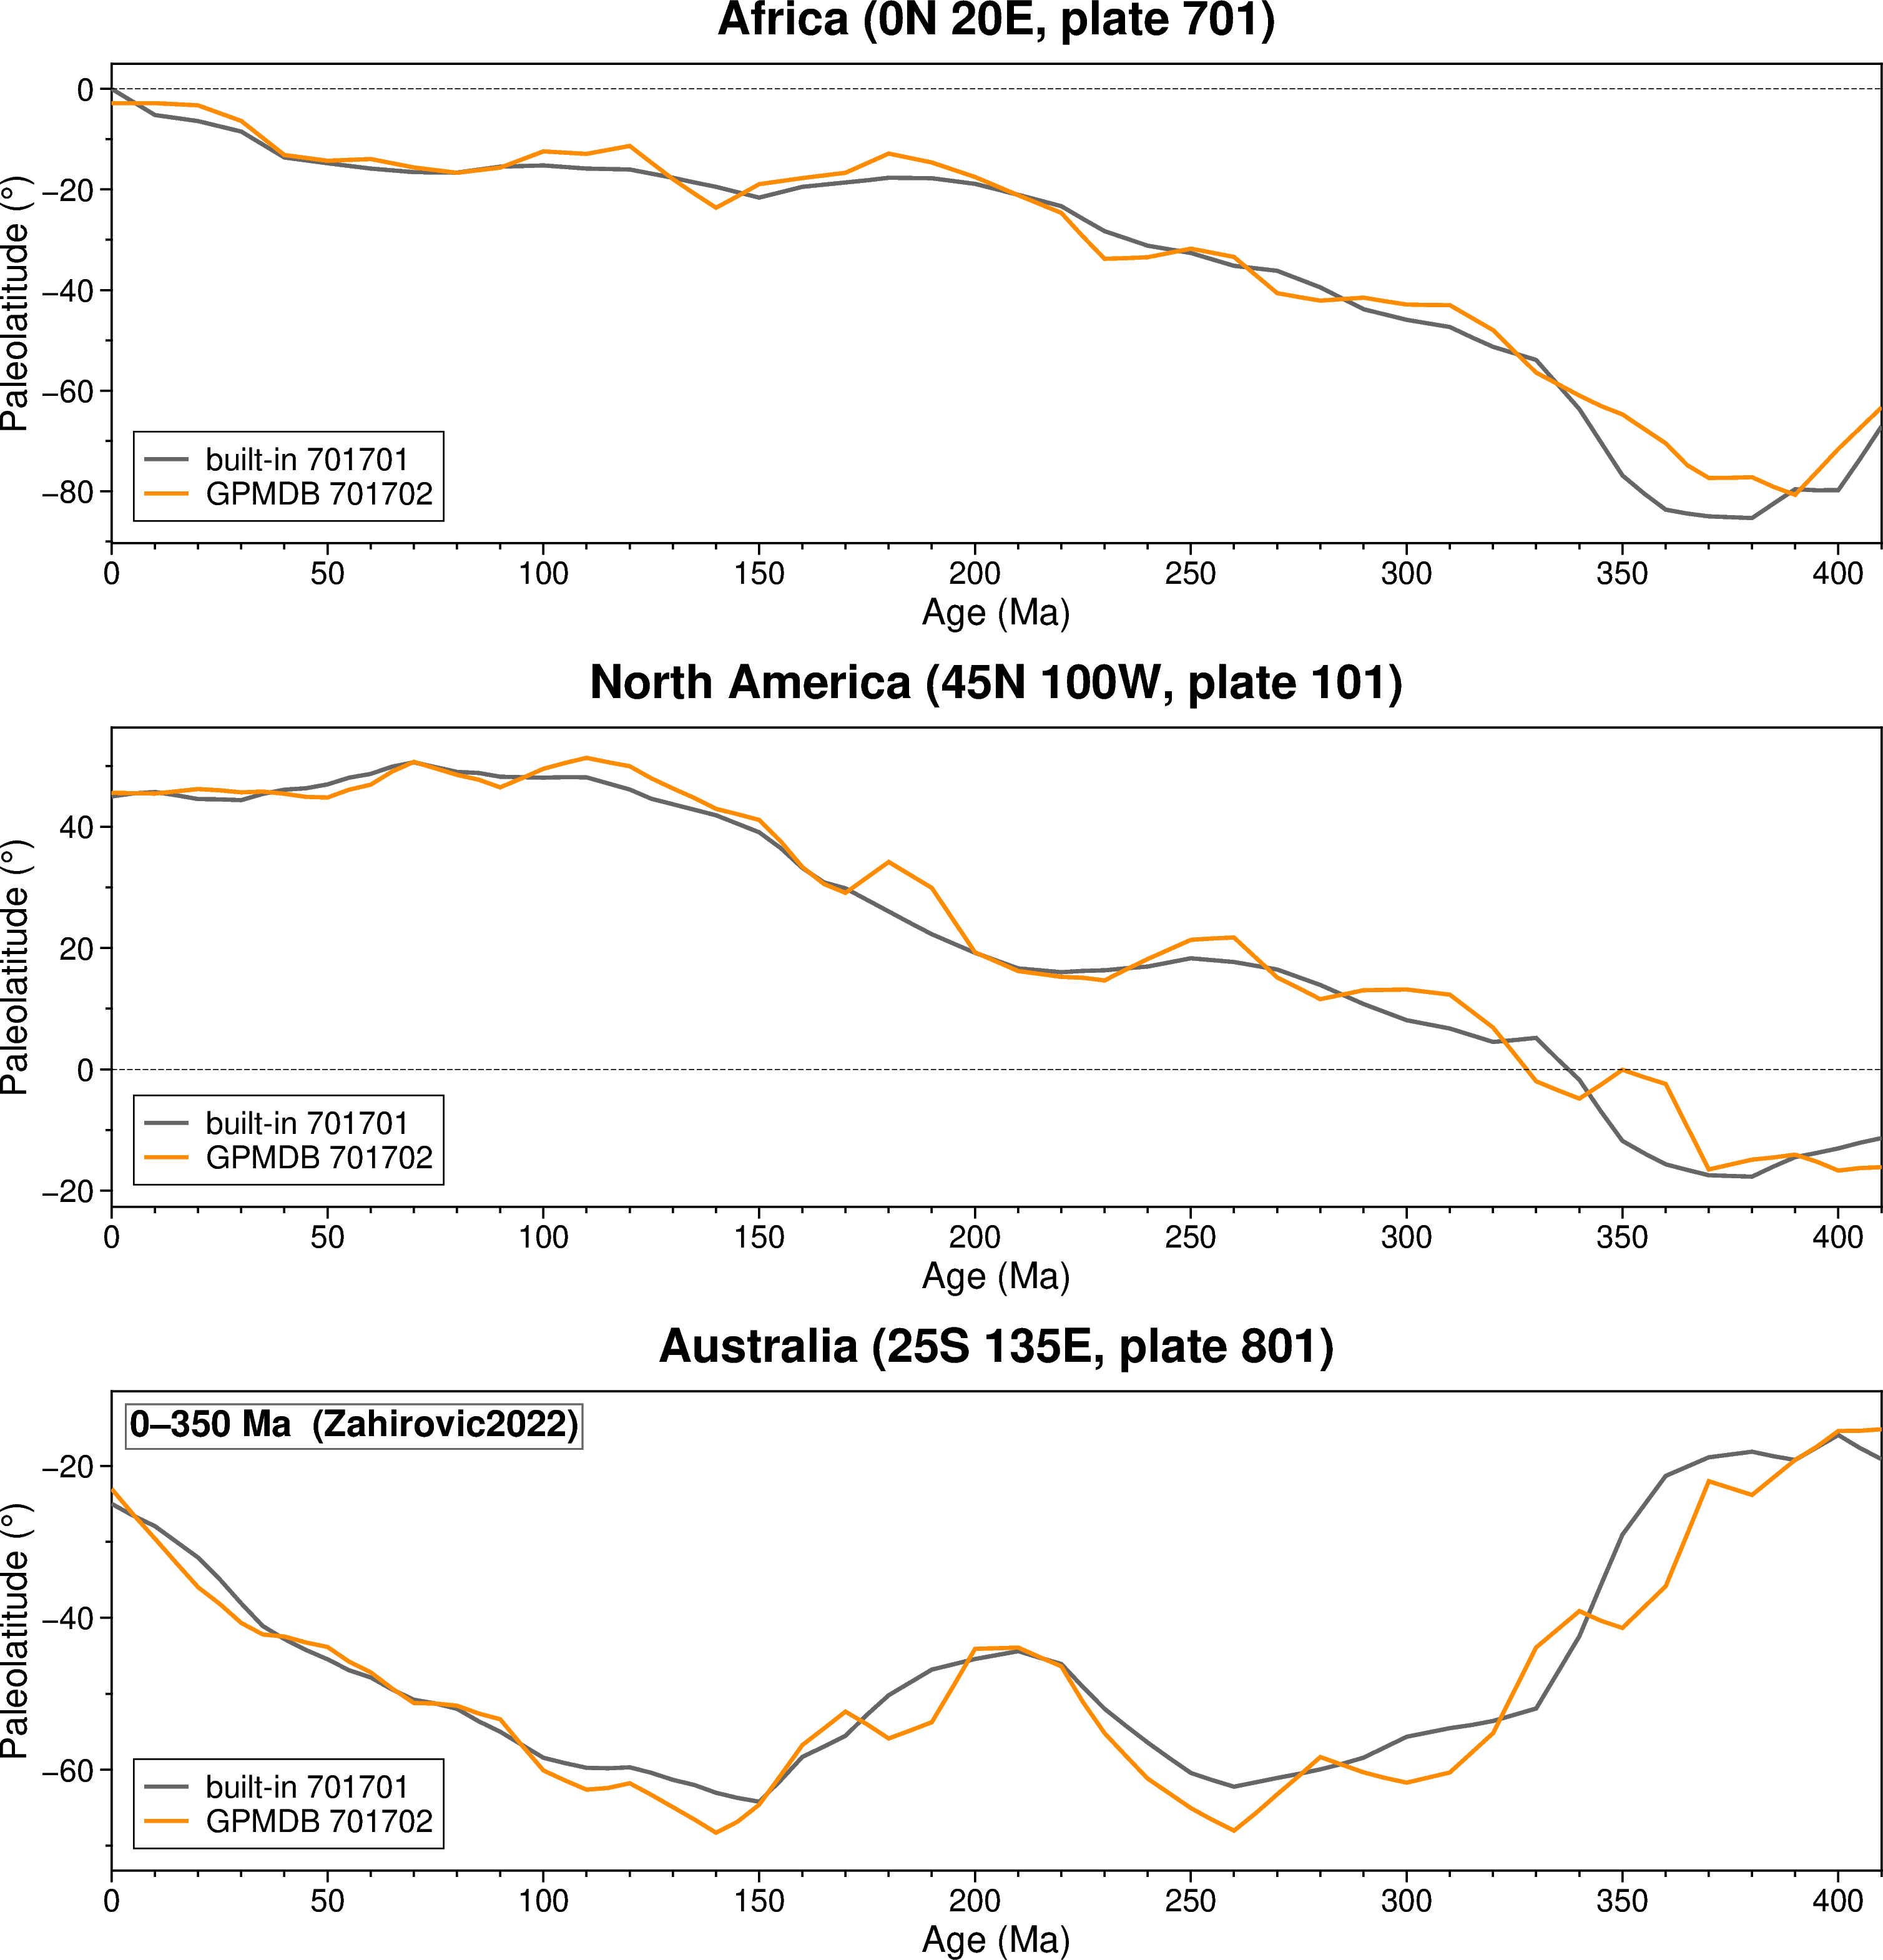

In [11]:
# Cell 4 — paleolatitude histories (one fitted panel per continent)
REF_POINTS = {"Africa (0N 20E, plate 701)": (701, 0, 20),
              "North America (45N 100W, plate 101)": (101, 45, -100),
              "Australia (25S 135E, plate 801)": (801, -25, 135)}
ages = np.arange(0, 411, 5)
PENS = {FRAME_A: "1.5p,gray40", FRAME_B: "1.5p,darkorange"}

fig = pygmt.Figure()
for i, (name, (pid, la, lo)) in enumerate(REF_POINTS.items()):
    if i > 0:
        fig.shift_origin(yshift="-9c")
    pt = pygplates.PointOnSphere(la, lo)
    series = {}
    for anchor in (FRAME_A, FRAME_B):
        rm = recon[anchor].rotation_model
        series[anchor] = [(rm.get_rotation(float(t), pid) * pt).to_lat_lon()[0] for t in ages]
    lo_y = min(min(s) for s in series.values()) - 5
    hi_y = max(max(s) for s in series.values()) + 5
    fig.basemap(region=[0, 410, lo_y, hi_y], projection="X24c/6.5c",
                frame=["xaf+lAge (Ma)", "yaf+lPaleolatitude (\260)", f"+t{name}"])
    for anchor, lab in ((FRAME_A, "built-in 701701"), (FRAME_B, "GPMDB 701702")):
        fig.plot(x=ages, y=series[anchor], pen=PENS[anchor], label=lab)
    if lo_y < 0 < hi_y:
        fig.plot(x=[0, 410], y=[0, 0], pen="0.25p,black,-")
    fig.legend(position="JBL+jBL+o0.3c", box="+gwhite+p0.5p")
fig.text(text=f"0–350 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)


## 3. Animate the difference: MP4 through the full model span

A frame every `CADENCE_MYR` Myr (user variable), rendered oldest-first so alphabetical frame order equals chronological order (the T06 convention), then assembled with ffmpeg. The same grey-fill / blue-line layering as the static maps.


In [ ]:
# Cell 5 — render frames and assemble the MP4
CADENCE_MYR = 5            # user variable: time step between video frames
START, END = 410, 0
FRAME_DIR = "frames_pmag_comparison"
os.makedirs(FRAME_DIR, exist_ok=True)

times = np.arange(START, END - 1, -CADENCE_MYR)
for i, age in enumerate(times):
    fig = pygmt.Figure()
    fig.basemap(region="d", projection="R0/26c",
                frame=["af", f"+t{age:.0f} Ma: built-in pmag frame (grey) vs GPMDB frame (blue)"])
    plot_frame_comparison(fig, age)
    fig.savefig(f"{FRAME_DIR}/frame_{i:04d}.png", dpi=150)
    if i % 10 == 0:
        print(f"  rendered {age:.0f} Ma ({i + 1}/{len(times)})")

# Encode as a cross-platform MP4 (same pattern as T06): the pad filter rounds
# odd frame dimensions up to even pixels - libx264 + yuv420p requires even
# width AND height, and pyGMT's tight bounding-box crop often produces odd dims.
subprocess.run([
    "ffmpeg", "-y",
    "-framerate", "8",
    "-pattern_type", "glob",
    "-i", f"{FRAME_DIR}/frame_*.png",
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2:color=white",
    "-movflags", "+faststart",
    "-crf", "20",
    "pmag_frame_comparison.mp4",
], check=True)
print("Wrote pmag_frame_comparison.mp4")


  rendered 410 Ma (1/83)


## Extend this

- Add a third frame: rebuild T23 with `Q_MIN = 2` or `4`, embed it as `701703`, and overlay it in a second line colour.
- Plot the great-circle distance between the two frames' reconstructed Africa through time — where does the divergence peak, and does it coincide with sparse intervals in the T23 APWP?
- Mask the comparison to times where the T23 APWP has A95 < 10° to see only the well-constrained signal.
- Swap the coastlines for continental polygons, or add the plate-boundary backbone (see T01) to the base frame only.


## References

- Torsvik, T.H. et al. (2012). Phanerozoic polar wander, palaeogeography and dynamics. *Earth-Science Reviews* 114, 325–368.
- Doubrovine, P.V. et al. (2012). Absolute plate motions in a reference frame defined by moving hotspots. *J. Geophys. Res.* 117, B09101.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
